# 01. 베이지안 추론 기초

PFN이 근사하려는 대상은 **posterior predictive distribution(PPD)** $p(y \mid x, D)$이며, PPD는 **베이지안 추론**의 최종 산출물입니다.

이 노트북은 뒤 챕터를 따라가는 데 필요한 최소한의 베이지안 토대를, 수식보다 **직관과 그림** 중심으로 이해합니다.

다루는 흐름:

1. 베이즈 정리 — prior · likelihood · posterior
2. 데이터가 쌓이면 posterior가 어떻게 좁아지는가 (동전 예제)
3. 점추정(MLE/MAP) vs 완전 베이지안
4. **PPD** — posterior 위에서 평균낸 예측 (이 노트북의 심장)
5. 선형 회귀로 "PPD는 왜 적분인가" 확인

## `pfn_cookbook` 불러오기

로컬에서는 `uv sync`로 패키지가 설치되어 있습니다. Databricks처럼 패키지가 설치되지 않은 환경에서는 저장소의 `src/`를 import 경로에 추가합니다. 모든 챕터 노트북은 이 셀로 시작합니다.

In [1]:
try:
    import pfn_cookbook
except ImportError:
    import sys
    from pathlib import Path

    sys.path.insert(0, str(Path.cwd().parent / "src"))
    import pfn_cookbook

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta

from pfn_cookbook import set_seed

set_seed(0)  # 재현성을 위해 난수 시드를 고정한다.

## 베이즈 정리 — prior, likelihood, posterior

데이터 $D$를 보고 미지의 파라미터 $\theta$에 대한 믿음(degree of belief) 을 갱신하는 규칙입니다.

$$
\underbrace{p(\theta \mid D)}_{\text{posterior}}
= \frac{\overbrace{p(D \mid \theta)}^{\text{likelihood}}\;\overbrace{p(\theta)}^{\text{prior}}}
       {\underbrace{p(D)}_{\text{evidence}}}
\;\;\propto\;\; p(D \mid \theta)\,p(\theta)
$$

- **prior** $p(\theta)$ — 데이터를 보기 전 $\theta$에 대한 믿음
- **likelihood** $p(D \mid \theta)$ — $\theta$가 주어졌을 때 이 데이터가 나올 가능성
- **posterior** $p(\theta \mid D)$ — 데이터를 본 뒤 갱신된 믿음
- **evidence** $p(D)$ — $\theta$를 적분해 없앤 정규화 상수

핵심은 마지막 비례식입니다. **posterior는 prior와 likelihood를 곱한 것에 비례**합니다.

## 데이터가 쌓이면 posterior가 좁아진다 — 동전 던지기

앞면이 나올 확률 $\theta$를 모르는 동전을 생각합니다. 던진 결과(앞/뒤)가 likelihood이고, $\theta$에 대한 믿음을 $\mathrm{Beta}(a, b)$ 분포로 둡니다. Beta는 Bernoulli의 conjugate prior 라, 앞면 $h$번·뒷면 $t$번을 관측하면 posterior도 다시 Beta 분포가 됩니다.

$$
\theta \sim \mathrm{Beta}(a, b), \qquad
\theta \mid D \sim \mathrm{Beta}(a + h,\; b + t)
$$

확률이 $0.7$인 동전을 던져가며, 관측 수 $n$이 늘 때 posterior가 어떻게 실제 값 주변으로 좁아지는지 봅니다.

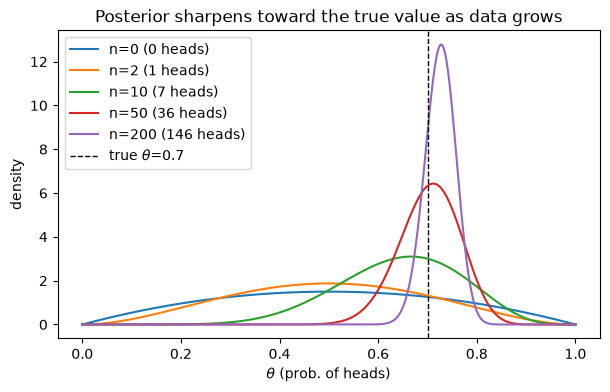

In [3]:
true_p = 0.7
flips = (np.random.rand(200) < true_p).astype(int)  # 1=앞면, 0=뒷면

a0, b0 = 2.0, 2.0  # prior: Beta(2, 2) — 0.5 근처를 완만하게 선호
grid = np.linspace(0, 1, 500)

fig, ax = plt.subplots(figsize=(7, 4))
for n in [0, 2, 10, 50, 200]:
    heads = flips[:n].sum()
    tails = n - heads
    post = beta(a0 + heads, b0 + tails)
    ax.plot(grid, post.pdf(grid), label=f"n={n} ({heads} heads)")

ax.axvline(true_p, color="black", ls="--", lw=1, label=rf"true $\theta$={true_p}")
ax.set_xlabel(r"$\theta$ (prob. of heads)")
ax.set_ylabel("density")
ax.set_title("Posterior sharpens toward the true value as data grows")
ax.legend()
plt.show()

## Point Estimation (MLE/MAP) vs full Bayesian

$\theta$ 하나만 고르는 방법도 있습니다.

- **MLE** (최대가능도): likelihood만 최대화 → 동전에선 $\hat\theta = h / n$
- **MAP** (최대사후): posterior를 최대화 → prior가 끼어든 값

둘 다 **점 하나**로 답합니다. 데이터가 적으면 이 점은 과적합되기 쉽습니다($n=1$에 앞면이 나오면 MLE는 $\theta=1.0$이라고 단언).  
반면 **완전 베이지안은 posterior라는 분포 전체**를 들고 가면서 불확실성을 함께 표현합니다.

이 차이가 다음의 PPD에서 결정적입니다.

## Posterior Predictive Distribution

우리가 실제로 원하는 건 파라미터 $\theta$가 아니라 **다음 관측 $y$에 대한 예측**입니다. 파라미터를 하나로 고정하지 않고, **posterior 위에서 평균**내 구합니다.

$$
p(y \mid x, D) \;=\; \int p(y \mid x, \theta)\; p(\theta \mid D)\; d\theta
$$

"가능한 모든 $\theta$에 대해, 그 $\theta$가 얼마나 그럴듯한지($p(\theta \mid D)$)로 가중해서 예측을 섞는다"는 뜻입니다. 점추정은 이 적분을 $\theta=\hat\theta$ 한 점으로 대체해버린 근사에 불과합니다.

동전 예제에서 다음 던지기가 앞면일 PPD는 posterior 평균으로 딱 떨어집니다.

$$
p(y=1 \mid D) = \int \theta \; p(\theta \mid D)\, d\theta
= \mathbb{E}[\theta \mid D] = \frac{a + h}{a + b + n}
$$

$n$이 작을 때 이 값이 MLE와 얼마나 다른지 봅니다.

In [4]:
print(f"{'n':>4} {'MLE (h/n)':>12} {'PPD (베이지안)':>16}")
for n in [0, 1, 2, 5, 20, 200]:
    heads = flips[:n].sum()
    mle = heads / n if n > 0 else float("nan")
    ppd = (a0 + heads) / (a0 + b0 + n)  # posterior 평균
    print(f"{n:>4} {mle:>12.3f} {ppd:>16.3f}")

print("\n관측이 거의 없을 때 MLE는 0/1로 튀지만, PPD는 prior 덕에 완만하게 움직인다.")

   n    MLE (h/n)       PPD (베이지안)
   0          nan            0.500
   1        1.000            0.600
   2        0.500            0.500
   5        0.800            0.667
  20        0.600            0.583
 200        0.730            0.725

관측이 거의 없을 때 MLE는 0/1로 튀지만, PPD는 prior 덕에 완만하게 움직인다.


## 선형 회귀

$$
p(y \mid x_*, D) = \int p(y \mid x_*, w)\; p(w \mid D)\; dw
$$

위 수식을 풀면  **"가능한 모든 $w$에 대해, 그 $w$가 데이터에 비춰 얼마나 그럴듯한지($p(w \mid D)$)로 가중해서 예측 $p(y \mid x_*, w)$을 평균낸다"** 입니다.  
손으로 적분이 풀릴 수 있을 때는 닫힌형 정답이 존재합니다.

만약 손으로 적분이 안 풀릴 땐 **posterior에서 $w$를 샘플링 해서 예측의 평균**내면 됩니다(몬테카를로 적분):

$$
p(y \mid x_*, D) \;\approx\; \frac{1}{S}\sum_{i=1}^{S} p(y \mid x_*, w_i), \qquad w_i \sim p(w \mid D)
$$

선형 회귀는 이 적분에 **닫힌형 정답**이 있어서, "표본 평균 ≈ 적분"을 눈으로 대조할 수 있습니다.  
모델: $y = w_0 + w_1 x + \varepsilon$, $\varepsilon \sim \mathcal{N}(0,\sigma^2)$, prior $w \sim \mathcal{N}(0, \alpha^2 I)$.

In [5]:
# 데이터 생성 + posterior 닫힌형
x_train = np.linspace(-3, 3, 12)
w_true = np.array([0.5, 1.2])
sigma = 0.5
Phi = np.stack([np.ones_like(x_train), x_train], axis=1)
y_train = Phi @ w_true + sigma * np.random.randn(x_train.size)

alpha = 3.0  # 가중치 prior 표준편차
S = np.linalg.inv(np.eye(2) / alpha**2 + Phi.T @ Phi / sigma**2)  # posterior 공분산
m = S @ Phi.T @ y_train / sigma**2                               # posterior 평균

# 쿼리 지점(외삽 영역이라 파라미터 불확실성이 잘 드러난다)
x_q = 4.0
phi_q = np.array([1.0, x_q])

# (1) 닫힌형 PPD: 가우시안
ppd_mean = phi_q @ m
ppd_var = sigma**2 + phi_q @ S @ phi_q
ppd_std = np.sqrt(ppd_var)

# (2) 몬테카를로: posterior에서 w를 뽑아 예측을 섞는다 = 적분 근사
W = np.random.multivariate_normal(m, S, size=20000)   # w_i ~ p(w|D)
f_q = W @ phi_q                                        # 각 w의 예측(노이즈 전)
y_q = f_q + sigma * np.random.randn(W.shape[0])        # + 관측 노이즈 => PPD 표본

print(f"           {'mean':>8} {'std':>8}")
print(f"closed-form {ppd_mean:>8.3f} {ppd_std:>8.3f}   <- 적분을 손으로 푼 값")
print(f"Monte Carlo {y_q.mean():>8.3f} {y_q.std():>8.3f}   <- posterior 표본 평균")

               mean      std
closed-form    4.984    0.604   <- 적분을 손으로 푼 값
Monte Carlo    4.985    0.602   <- posterior 표본 평균


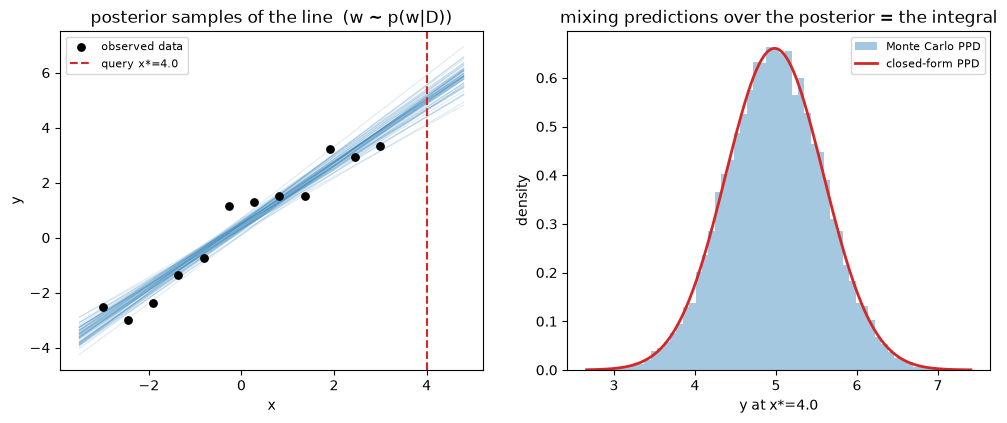

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# 왼쪽: posterior에서 뽑은 '그럴듯한 직선'들 — 이것들을 섞는 게 적분
ax = axes[0]
x_line = np.linspace(-3.5, 4.8, 100)
Phi_line = np.stack([np.ones_like(x_line), x_line], axis=1)
for w in W[:60]:
    ax.plot(x_line, Phi_line @ w, color="C0", alpha=0.15, lw=0.8)
ax.scatter(x_train, y_train, c="black", s=28, zorder=5, label="observed data")
ax.axvline(x_q, color="C3", ls="--", lw=1.5, label=f"query x*={x_q}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("posterior samples of the line  (w ~ p(w|D))")
ax.legend(loc="upper left", fontsize=8)

# 오른쪽: x*에서 예측을 섞은 히스토그램 = PPD, 닫힌형 가우시안과 대조
ax = axes[1]
ax.hist(y_q, bins=60, density=True, color="C0", alpha=0.4, label="Monte Carlo PPD")
grid = np.linspace(y_q.min(), y_q.max(), 300)
gauss = np.exp(-0.5 * ((grid - ppd_mean) / ppd_std) ** 2) / (ppd_std * np.sqrt(2 * np.pi))
ax.plot(grid, gauss, color="C3", lw=2, label="closed-form PPD")
ax.set_xlabel(f"y at x*={x_q}")
ax.set_ylabel("density")
ax.set_title("mixing predictions over the posterior = the integral")
ax.legend(fontsize=8)
plt.show()